In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
df=pd.read_csv(r'C:\Users\Lenovo\OneDrive\Desktop\training\.venv\Scripts\Projects\Preprocessed_Data.csv')
df.head(5)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [9]:
X = df.drop("tenure", axis=1)
y = df["tenure"]
X = pd.get_dummies(X, drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)

print("Training Target:", y_train.shape)
print("Testing Target :", y_test.shape)
print("Training Data")
print(X_train.head())
print("\nTesting Data")
print(X_test.head())


Training Features: (5634, 13601)
Testing Features : (1409, 13601)
Training Target: (5634,)
Testing Target : (1409,)
Training Data
      SeniorCitizen  MonthlyCharges  customerID_0003-MKNFE  \
2142              0           64.85                  False   
1623              0           97.20                  False   
6074              0           23.45                  False   
1362              0           70.20                  False   
6754              0           61.90                  False   

      customerID_0004-TLHLJ  customerID_0011-IGKFF  customerID_0013-EXCHZ  \
2142                  False                  False                  False   
1623                  False                  False                  False   
6074                  False                  False                  False   
1362                  False                  False                  False   
6754                  False                  False                  False   

      customerID_0013-MHZWF  custo

In [ ]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [10]:
df["tenure"]

0        1
1       34
2        2
3       45
4        2
        ..
7038    24
7039    72
7040    11
7041     4
7042    66
Name: tenure, Length: 7043, dtype: int64

In [4]:
df["MonthlyCharges"].astype(float)

0        29.85
1        56.95
2        53.85
3        42.30
4        70.70
         ...  
7038     84.80
7039    103.20
7040     29.60
7041     74.40
7042    105.65
Name: MonthlyCharges, Length: 7043, dtype: float64

In [11]:
X = df['MonthlyCharges']
Y = df['tenure']
m = ((X - X.mean())*(Y - Y.mean()))/((X - X.mean())**2).sum()
c=Y.mean() - m*X.mean()
Y_pred = m*X+c
print(Y_pred)
Y_pred = np.round(Y_pred).astype(int)
print(Y_pred.head())
print("Slope: ",m)
print("Intercept: ",c)

0       32.365152
1       32.371164
2       32.370582
3       32.372148
4       32.370981
          ...    
7038    32.370621
7039    32.380332
7040    32.367005
7041    32.370735
7042    32.379967
Length: 7043, dtype: float64
0    32
1    32
2    32
3    32
4    32
dtype: int64
Slope:  0       0.000172
1      -0.000002
2       0.000052
3      -0.000044
4      -0.000028
          ...   
7038   -0.000026
7039    0.000239
7040    0.000118
7041   -0.000043
7042    0.000216
Length: 7043, dtype: float64
Intercept:  0       32.360024
1       32.371278
2       32.367783
3       32.374030
4       32.372981
          ...    
7038    32.372852
7039    32.355676
7040    32.363516
7041    32.373926
7042    32.357182
Length: 7043, dtype: float64


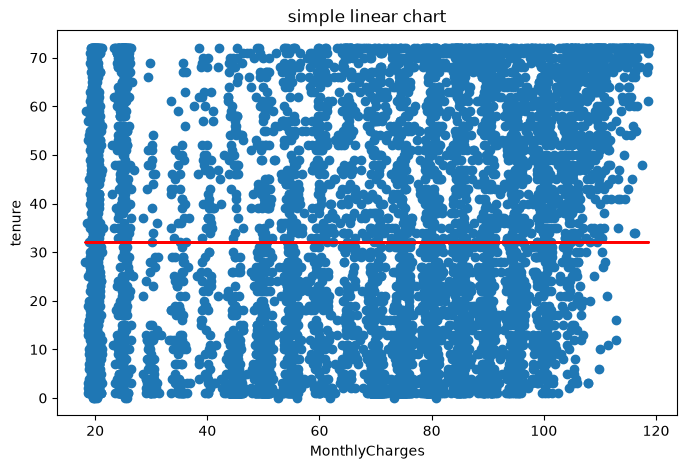

In [12]:
plt.figure(figsize=(8,5))
plt.scatter(X,Y)
plt.plot(X,Y_pred,color="red")
plt.title("simple linear chart")
plt.xlabel("MonthlyCharges")
plt.ylabel("tenure")
plt.show()

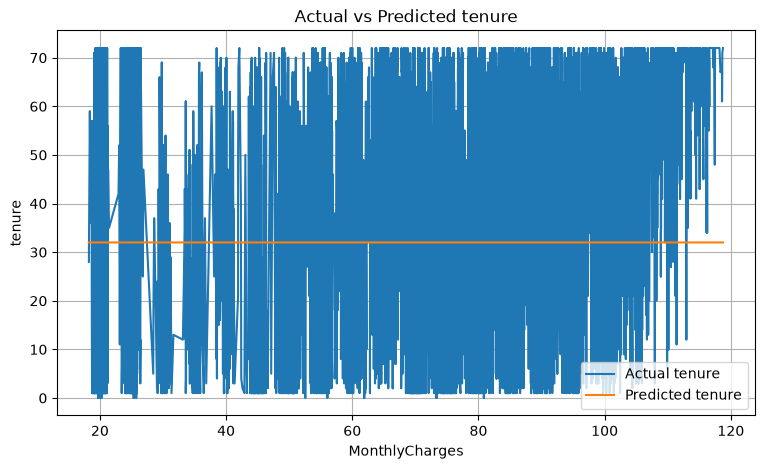

In [13]:
sorted_data = pd.DataFrame({
    "X":X,
    "Actual" : Y,
    "Predicted":Y_pred
}).sort_values("X")
plt.figure(figsize=(9,5))
plt.plot(sorted_data["X"],sorted_data["Actual"],label="Actual tenure")
plt.plot(sorted_data["X"],sorted_data["Predicted"],label="Predicted tenure")
plt.title("Actual vs Predicted tenure")
plt.xlabel("MonthlyCharges")
plt.ylabel("tenure")
plt.legend()
plt.grid(True)
plt.show()